  valueCategory  temporal temporal_type georegion georegion_type agegroup  \
0         cases  2020-W09      iso_week        AG         canton      all   
1         cases  2020-W09      iso_week        AI         canton      all   
2         cases  2020-W09      iso_week        AR         canton      all   
3         cases  2020-W09      iso_week        BE         canton      all   
4         cases  2020-W09      iso_week        BL         canton      all   

      agegroup_type  sex testResult testResult_type  value        pop  \
0  agegroup_ili_ari  all   positive             all    5.0   694072.0   
1  agegroup_ili_ari  all   positive             all    0.0    16293.0   
2  agegroup_ili_ari  all   positive             all    0.0    55309.0   
3  agegroup_ili_ari  all   positive             all    2.0  1043132.0   
4  agegroup_ili_ari  all   positive             all    4.0   290969.0   

   incValue  prct  inc14d  dataComplete  
0      0.72   8.8     NaN          True  
1      0.00   

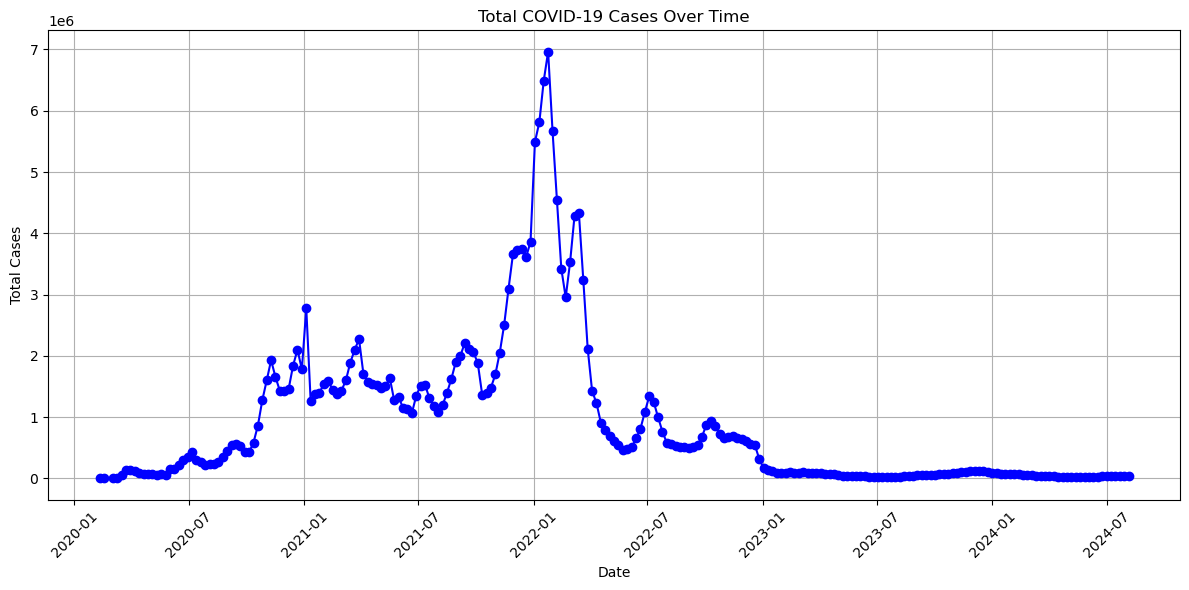

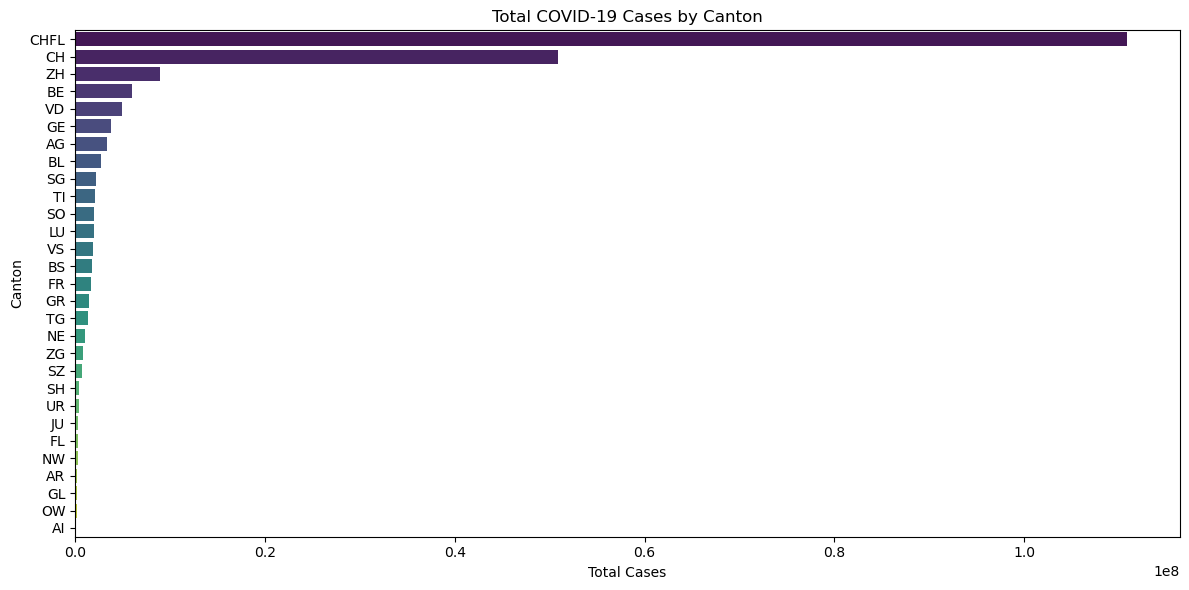

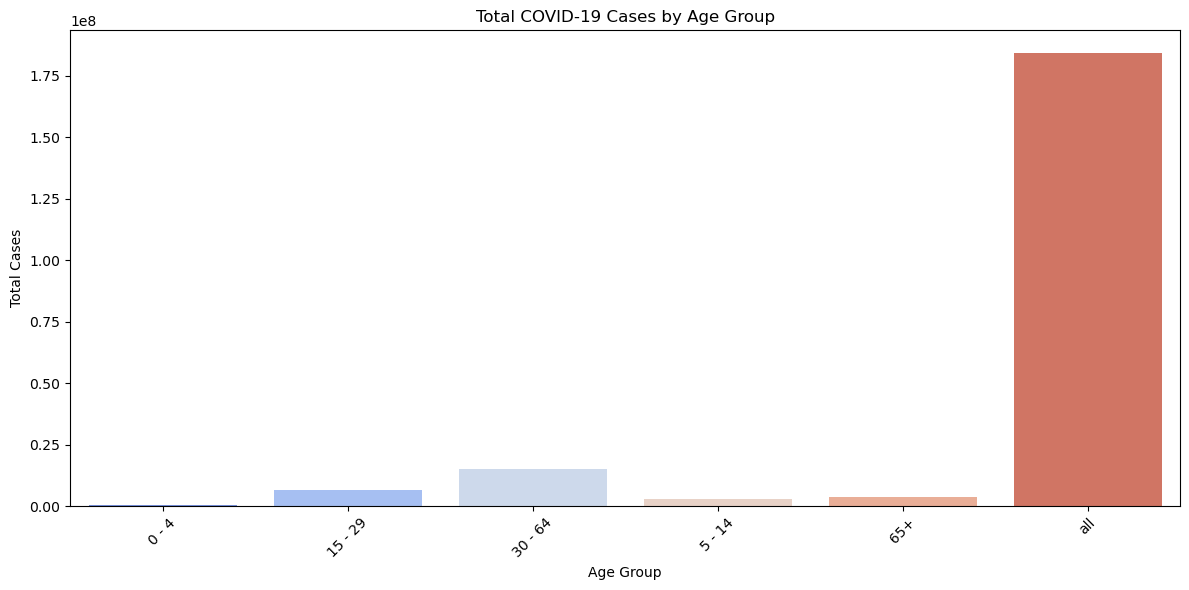

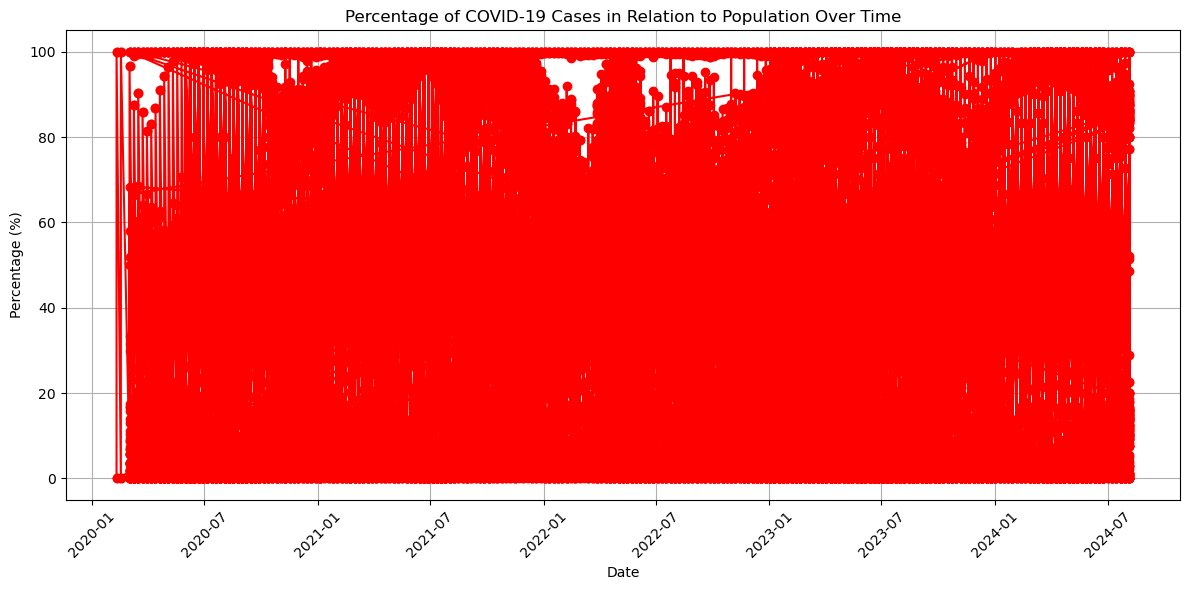

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
url = 'https://idd.bag.admin.ch/api/v1/export/current/COVID19_oblig/csv'
data = pd.read_csv(url)

# Inspect the first few rows of the dataframe
print(data.head())

# Data Cleaning and Preparation
# Convert 'temporal' to datetime
data['temporal'] = pd.to_datetime(data['temporal'] + '-1', format='%Y-W%W-%w')

# Filter relevant columns and handle missing values
data = data[['temporal', 'georegion', 'agegroup', 'value', 'pop', 'prct']].dropna()

# Aggregate data to visualize trends
weekly_cases = data.groupby('temporal').agg({'value': 'sum'}).reset_index()

# Plot total cases over time
plt.figure(figsize=(12, 6))
plt.plot(weekly_cases['temporal'], weekly_cases['value'], marker='o', linestyle='-', color='b')
plt.title('Total COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot cases distribution by region (canton)
canton_cases = data.groupby('georegion').agg({'value': 'sum'}).sort_values(by='value', ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='value', y='georegion', data=canton_cases, palette='viridis')
plt.title('Total COVID-19 Cases by Canton')
plt.xlabel('Total Cases')
plt.ylabel('Canton')
plt.tight_layout()
plt.show()

# Plot age group distribution of cases
age_group_cases = data.groupby('agegroup').agg({'value': 'sum'}).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='agegroup', y='value', data=age_group_cases, palette='coolwarm')
plt.title('Total COVID-19 Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot percentage of cases in relation to population over time
plt.figure(figsize=(12, 6))
plt.plot(data['temporal'], data['prct'], marker='o', linestyle='-', color='r')
plt.title('Percentage of COVID-19 Cases in Relation to Population Over Time')
plt.xlabel('Date')
plt.ylabel('Percentage (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
